In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
import yaml
import pandas as pd
import numpy as np
from src.data import load_modeling_data
from src.features import create_features
from src.split import time_based_split, create_xy
from src.artifacts import load_artifacts
from src.evaluation import evaluate_at_threshold
from src.config import load_config

In [11]:
import os
os.chdir("..")
config = load_config("configs/config.yaml")
table_name=config["data"]["table_name"]
df= load_modeling_data(table_name)
df= create_features(df)
train_df, val_df, test_df=  time_based_split(
    df=df,
    validation_start=config["split"]["validation_start"],
    test_start=config["split"]["test_start"],
)
target_column = config["data"]["target_column"]
X_train, y_train = create_xy(
    train_df,
    target_column=target_column,
)
X_val, y_val = create_xy(
        val_df,
        target_column=target_column,
)

X_test, y_test = create_xy(
    test_df,
    target_column=target_column,
)

In [14]:
pipeline, model_info = load_artifacts()
threshold = model_info["threshold"]
threshold 

0.2574331564883078

In [15]:
y_proba_test= pipeline.predict_proba(X_test)[:, 1]
y_pred_test= (y_proba_test>= threshold).astype(int)

c:\Users\Пользователь\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [21]:
cm=model_info["test_metrics"].get("confusion_matrix")
tn, fp, fn, tp =  (cm[0][0], cm[0][1], cm[1][0], cm[1][1])

print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

TN: 136468, FP: 26293, FN: 27941, TP: 15399


In [23]:
error_df = X_test.copy()
error_df["y_true"] = y_test.values
error_df["y_proba"] = y_proba_test
error_df["y_pred"] = y_pred_test
conditions = [
    (error_df["y_true"] == 0) & (error_df["y_pred"] == 0),
    (error_df["y_true"] == 0) & (error_df["y_pred"] == 1),
    (error_df["y_true"] == 1) & (error_df["y_pred"] == 0),
    (error_df["y_true"] == 1) & (error_df["y_pred"] == 1),
]
choices = ["TN", "FP", "FN", "TP"]

error_df["error_type"] = np.select(conditions, choices, default="Unknown")

In [26]:
error_df["error_type"].value_counts()


error_type
TN    136468
FN     27941
FP     26293
TP     15399
Name: count, dtype: int64

# term

In [51]:
pivot_table = (
    error_df
    .groupby(["term_months", "error_type"])
    .size()
    .unstack(fill_value=0)
)

In [52]:
pivot_table["applications"] = error_df.groupby("term_months").size()

In [53]:
pivot_table["actual_defaults"] = error_df.groupby("term_months")["y_true"].sum()

In [54]:

pivot_table["FN_rate"] = pivot_table["FN"] / (pivot_table["FN"] + pivot_table["TP"])

In [55]:
pivot_table["flagged_rate"] = (pivot_table["FP"] + pivot_table["TP"]) / pivot_table["applications"]

In [63]:
pivot_table['recall']= pivot_table["TP"]/ pivot_table["actual_defaults"]

In [64]:
pivot_table

error_type,FN,FP,TN,TP,applications,actual_defaults,FN_rate,flagged_rate,recall
term_months,,,,,,,,,
36,24846,4632,121962,3370,154810,28216,0.880564,0.051689,0.119436
60,3095,21661,14506,12029,51291,15124,0.204642,0.656840,0.795358


| Term      | Actual defaults |     FN |     TP |   FN rate | Recall | Flagged rate |
| --------- | --------------: | -----: | -----: | --------: | -----: | -----------: |
| 36 months |          28,216 | 24,846 |  3,370 | **88.1%** |  11.9% |         5.2% |
| 60 months |          15,124 |  3,095 | 12,029 | **20.5%** |  79.5% |        65.7% |


The model detects defaults effectively among 60-month loans but performs poorly on 36-month loans, where most actual defaults are classified as safe. This suggests substantial dependence on loan term and a possible need for segment-specific thresholds or additional predictive features.

In [43]:
error_df['purpose'].value_counts()

purpose
debt_consolidation    113234
credit_card            39585
home_improvement       16789
other                  16543
OTHER                   6942
major_purchase          5529
medical                 3465
small_business          2182
moving                  1832
Name: count, dtype: int64

In [69]:
purpose = (
    error_df
    .groupby(["purpose", "error_type"])
    .size()
    .unstack(fill_value=0)
)

In [70]:
purpose["applications"] = error_df.groupby("purpose").size()

In [71]:
purpose["actual_defaults"] = error_df.groupby("purpose")["y_true"].sum()

In [72]:

purpose["FN_rate"] = purpose["FN"] / (purpose["FN"] + purpose["TP"])

In [73]:
purpose["flagged_rate"] = (purpose["FP"] + purpose["TP"]) / purpose["applications"]

In [74]:
purpose["default_rate"]= purpose['actual_defaults']/purpose['applications']

In [75]:
purpose["recall"]= purpose['TP']/purpose['actual_defaults']

In [76]:
purpose["precision"]= purpose["TP"]/ (purpose["TP"]+purpose["FP"])

In [77]:
purpose

error_type,FN,FP,TN,TP,applications,actual_defaults,FN_rate,flagged_rate,default_rate,recall,precision
purpose,,,,,,,,,,,
OTHER,914,555,5147,326,6942,1240,0.737097,0.126909,0.178623,0.262903,0.370034
credit_card,5176,4070,28365,1974,39585,7150,0.723916,0.152684,0.180624,0.276084,0.326605
debt_consolidation,15136,16811,71468,9819,113234,24955,0.606532,0.235177,0.220384,0.393468,0.368719
home_improvement,2202,1702,12010,875,16789,3077,0.715632,0.153493,0.183275,0.284368,0.339542
major_purchase,784,585,3743,417,5529,1201,0.652789,0.181226,0.217218,0.347211,0.416168
medical,576,332,2321,236,3465,812,0.709360,0.163925,0.234343,0.290640,0.415493
moving,316,185,1171,160,1832,476,0.663866,0.188319,0.259825,0.336134,0.463768
other,2512,1582,11308,1141,16543,3653,0.687654,0.164601,0.220818,0.312346,0.419023
small_business,325,471,935,451,2182,776,0.418814,0.422548,0.355637,0.581186,0.489154


Error rates differ noticeably across loan purposes. The model performs best on small-business loans, where both default risk and recall are high. Debt consolidation produces the most false negatives simply because it is the largest category. Meanwhile, less common purposes like educational or wedding loans show weaker performance, suggesting the model struggles with segments that have limited data.

In [ ]:
error_df

,loan_amnt,home_ownership,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,...,term_months,emp_length_years,annual_inc_log,credit_history_length_years,y_true,y_proba,y_pred,error_type,annual_inc,income_segment
1097537,5000,RENT,debt_consolidation,21.91,0,0.0,5,0,5603,86.2,...,36,2,11.082158,12.18,0,0.111001,0,TN,65000.0,40–80k
1097538,35000,RENT,credit_card,8.31,1,0.0,8,0,15979,61.2,...,36,3,11.695255,20.52,1,0.121212,0,FN,120000.0,>120k
1097539,9000,OTHER,debt_consolidation,14.87,0,0.0,8,0,7228,38.0,...,36,6,10.404293,12.18,0,0.132878,0,TN,33000.0,≤40k
1097540,9300,MORTGAGE,debt_consolidation,5.46,1,0.0,11,0,6704,45.3,...,36,10,10.968216,19.60,0,0.098688,0,TN,58000.0,40–80k
1097541,10650,RENT,debt_consolidation,27.66,0,1.0,11,0,1936,12.8,...,60,4,10.621352,13.01,0,0.424555,1,FP,41000.0,40–80k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303633,12000,MORTGAGE,other,17.19,0,2.0,14,1,9678,49.9,...,36,10,10.859018,13.01,0,0.242597,0,TN,52000.0,40–80k
1303634,21000,MORTGAGE,credit_card,12.15,0,4.0,35,0,33766,14.7,...,60,3,11.736077,11.26,0,0.221165,0,TN,125000.0,>120k
1303635,23650,MORTGAGE,home_improvement,32.36,0,1.0,15,0,34960,61.3,...,60,2,12.160034,25.02,0,0.281429,1,FP,191000.0,>120k
1303636,10000,MORTGAGE,credit_card,9.36,0,0.0,6,0,7503,27.7,...,36,-1,10.126671,17.26,0,0.110523,0,TN,25000.0,≤40k


In [88]:
error_df["dti_segment"] = pd.cut(
    error_df["dti"],
    bins=[0, 10, 20, 30, 40, 100],
    labels=["0–10%", "10–20%", "20–30%", "30–40%", ">40%"],
    include_lowest=True,
)

In [89]:
dti_segment = (
    error_df
    .groupby(["dti_segment", "error_type"])
    .size()
    .unstack(fill_value=0)
)

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_11460\1602907059.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["dti_segment", "error_type"])


In [90]:
dti_segment["applications"] = error_df.groupby("dti_segment").size()
dti_segment["actual_defaults"] = error_df.groupby("dti_segment")["y_true"].sum()
dti_segment["default_rate"] = dti_segment["actual_defaults"] / dti_segment["applications"]
dti_segment["recall"] = dti_segment["TP"] / dti_segment["actual_defaults"]
dti_segment["precision"] = dti_segment["TP"] / (dti_segment["TP"] + dti_segment["FP"])
dti_segment["FN_rate"] = dti_segment["FN"] / (dti_segment["FN"] + dti_segment["TP"])
dti_segment["flagged_rate"] = (dti_segment["FP"] + dti_segment["TP"]) / dti_segment["applications"]


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_11460\2281403039.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dti_segment["applications"] = error_df.groupby("dti_segment").size()
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_11460\2281403039.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dti_segment["actual_defaults"] = error_df.groupby("dti_segment")["y_true"].sum()


In [91]:
dti_segment

error_type,FN,FP,TN,TP,applications,actual_defaults,default_rate,recall,precision,FN_rate,flagged_rate
dti_segment,,,,,,,,,,,
0–10%,5286,2793,31412,1689,41180,6975,0.169378,0.242151,0.376841,0.757849,0.108839
10–20%,10974,8198,59218,4471,82861,15445,0.186396,0.289479,0.352909,0.710521,0.152895
20–30%,8826,9626,35850,5819,60121,14645,0.243592,0.397337,0.376756,0.602663,0.256899
30–40%,2589,3923,8868,2610,17990,5199,0.288994,0.502020,0.399510,0.497980,0.363146
>40%,236,1389,962,686,3273,922,0.281699,0.744035,0.330602,0.255965,0.633975


Model performance varies substantially across DTI segments. Borrowers with higher DTI have higher observed default rates and are much more likely to be flagged for manual review. Recall increases from 24.2% in the lowest-DTI segment to 74.4% for borrowers with DTI above 40%. However, the model misses most defaults among borrowers with low or moderate DTI, indicating that it relies strongly on DTI-related risk signals and has difficulty detecting defaults when DTI is not extreme.

In [94]:
model = pipeline.named_steps["model"]
booster = model.booster_
importance_gain = booster.feature_importance(importance_type="gain")
importance_split = booster.feature_importance(importance_type="split")

In [102]:
preprocessor = pipeline.named_steps["prep"]
feature_names = preprocessor.get_feature_names_out()
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "gain": importance_gain,
    "split": importance_split,
})

In [103]:
feature_importance_df = feature_importance_df.sort_values("gain", ascending=False)
print(feature_importance_df.head(10))

                         feature           gain  split
9               num__term_months  178379.713657     59
1                       num__dti   34752.031787    182
11           num__annual_inc_log   34484.439884    239
7                num__revol_util   23244.591434    391
3            num__inq_last_6mths   22024.964313    132
6                 num__revol_bal   17915.322088    356
0                 num__loan_amnt   16949.297788    323
13  cat__home_ownership_MORTGAGE   12972.271705     45
16      cat__home_ownership_RENT   12210.175426     44
4                  num__open_acc   11915.533841    287


Gain-based feature importance shows that loan term is the dominant predictive feature, followed by DTI, annual income, revolving utilization, recent credit inquiries, and revolving balance. The strong importance of loan term is consistent with the error analysis: the model identifies defaults much more effectively among 60-month loans than among 36-month loans. This indicates that the model relies heavily on a small number of strong risk signals and may struggle to detect defaults when those signals are not extreme.

In [104]:
total_gain = feature_importance_df["gain"].sum()
feature_importance_df["gain_share"] = feature_importance_df["gain"] / total_gain
top15 = feature_importance_df.head(15).sort_values("gain", ascending=False)


In [115]:
import matplotlib.pyplot as plt


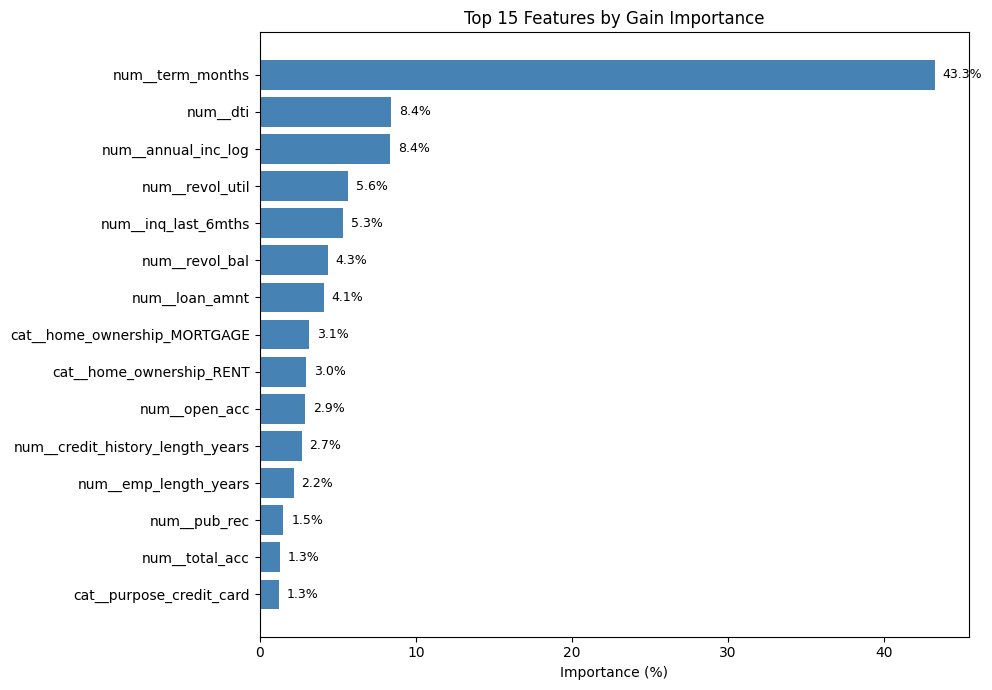

In [121]:
fig, ax = plt.subplots(figsize=(10, 7))
plt.barh(top15["feature"], top15["gain_p"], color="steelblue")
plt.xlabel("Importance (%)")
plt.title("Top 15 Features by Gain Importance")
plt.gca().invert_yaxis()  


for i, v in enumerate(top15["gain_p"]):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

output_path = PROJECT_ROOT / "reports" / "figures" / "feature_importance.png"
output_path.parent.mkdir(parents=True, exist_ok=True)

fig.tight_layout()
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

Loan term dominates the model, accounting for 43.3% of total gain importance. DTI and annual income are the next strongest predictors, each contributing about 8.4%. This agrees with the error analysis, where the model behaved very differently for 36-month and 60-month loans.

<Figure size 640x480 with 0 Axes>